#  Tests de Estacionariedad y Preparación DATA_VAR

Notebook de **estacionariedad avanzada** y preparación del dataset para modelos VAR/SVAR.

| Sección | Contenido |
|---------|-----------|
| 1 | Configuración (**única celda a editar**) |
| 2 | Carga de datos |
| 3 | Tests: ADF · PP · KPSS · Zivot-Andrews |
| 4 | Tabla resumen con semáforo de colores |
| 5 | Visualización por variable |
| 6 | 🎛️ Selector interactivo de transformaciones |
| 7 | Verificación post-transformación |
| 8 | Guardar `DATA_VAR.xlsx` |

> ✏️ **Solo edita la sección 1.** El resto corre automáticamente.


##  Dependencias
Ejecuta **una sola vez** si no tienes `arch` instalado.

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'arch', '--quiet'], check=False)
print(' Dependencias listas')

 Dependencias listas


##  Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

# ── Funciones del proyecto 
RUTA_FUNC = os.path.abspath(os.path.join('.', 'funciones'))
if RUTA_FUNC not in sys.path:
    sys.path.insert(0, RUTA_FUNC)

from funciones_estacionariedadp import (
    correr_todos,
    plot_variable_con_tests,
    construir_ui,
)
# Estilo de gráficos
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.edgecolor': '#CCCCCC',
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 1.0,
    'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
})

print('Imports correctos')

Imports correctos



## Configuración — **Edita solo aquí**

In [16]:
try:
    from filtro_datos import leer_data
    df = leer_data(ruta=RUTA_DATA, labels=LABELS)
except Exception as e:
    print(f" Error con filtro_datos: {e}")
    df = pd.read_excel(RUTA_DATA, index_col=0, parse_dates=True)
    df.index.name = 'Fecha'
    df = df.apply(pd.to_numeric, errors='coerce').rename(columns=LABELS)

print(f' Data cargada: {df.shape[0]} obs × {df.shape[1]} variables')
print(f'   Rango    : {df.index.min().date()} → {df.index.max().date()}')
print(f'   Variables: {list(df.columns)}')
df.head()

✅ Data cargada: 253 obs × 4 variables
   Rango: 2004-01-01 → 2025-01-01
   Variables: ['Expectativas Empresariales (3m)', 'Tasa de Referencia BCRP (%)', 'Crecimiento PBI (% interanual)', 'Términos de Intercambio (var%)']
 Data cargada: 253 obs × 4 variables
   Rango    : 2004-01-01 → 2025-01-01
   Variables: ['Expectativas Empresariales (3m)', 'Tasa de Referencia BCRP (%)', 'Crecimiento PBI (% interanual)', 'Términos de Intercambio (var%)']


,Expectativas Empresariales (3m),Tasa de Referencia BCRP (%),Crecimiento PBI (% interanual),Términos de Intercambio (var%)
Fecha,,,,
2004-01-01,2.454857,55.518018,4.014198,1.540757
2004-02-01,2.466364,57.331438,3.489598,2.578151
2004-03-01,2.480967,57.345581,5.548964,2.017657
2004-04-01,2.561647,58.160295,5.038973,-0.741896
2004-05-01,2.608470,57.737945,4.176200,0.546153


## Tests de Estacionariedad
Cuatro tests complementarios con veredicto por **mayoría simple** (≥ 3 de 4).
| Test | H₀ | Rechaza H₀ → |
|------|----|--------------|
| **ADF** | Raíz unitaria | Estacionaria |
| **PP** | Raíz unitaria | Estacionaria |
| **KPSS** | Estacionaria | No estacionaria |
| **Zivot-Andrews** | Raíz unitaria (sin quiebre) | Estacionaria con quiebre estructural |

In [35]:
print('Corriendo tests... (puede tardar unos segundos)')
tabla_tests = correr_todos(df, alpha=ALPHA)
print(' Tests completados')

Corriendo tests... (puede tardar unos segundos)
                                 ADF stat  ADF p-val  PP stat  PP p-val  KPSS stat  KPSS p-val  ZA stat  ZA p-val  Votos I(0)
Variable                                                                                                                     
Expectativas Empresariales (3m)   -3.2714     0.0162  -2.5903    0.0950     0.1215      0.4903  -4.7857    0.0546           1
Tasa de Referencia BCRP (%)       -3.1227     0.0249  -3.0509    0.0304     1.4745      0.0002  -5.2951    0.0093           1
Crecimiento PBI (% interanual)    -3.9684     0.0016  -4.8534    0.0000     0.3755      0.0840  -5.7477    0.0016           2
Términos de Intercambio (var%)    -5.7106     0.0000 -13.5055    0.0000     0.0916      0.6283  -6.3613    0.0004           2
 Tests completados


---
## 5 · Visualización por variable

Serie temporal · Distribución · P-valores de los 4 tests

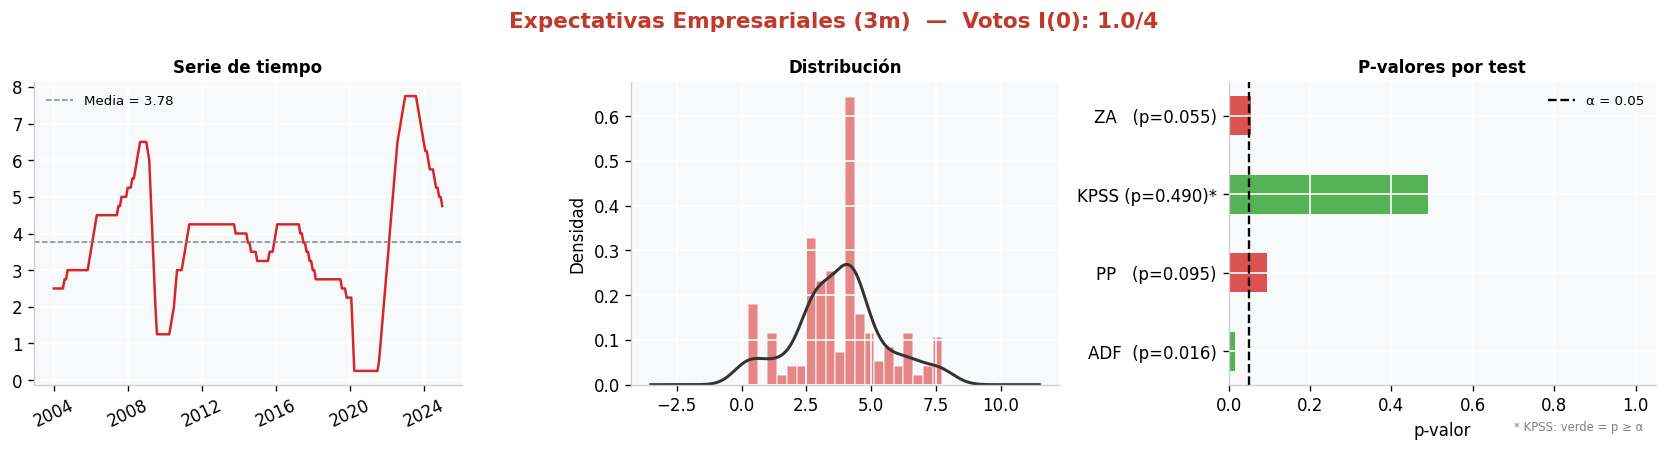

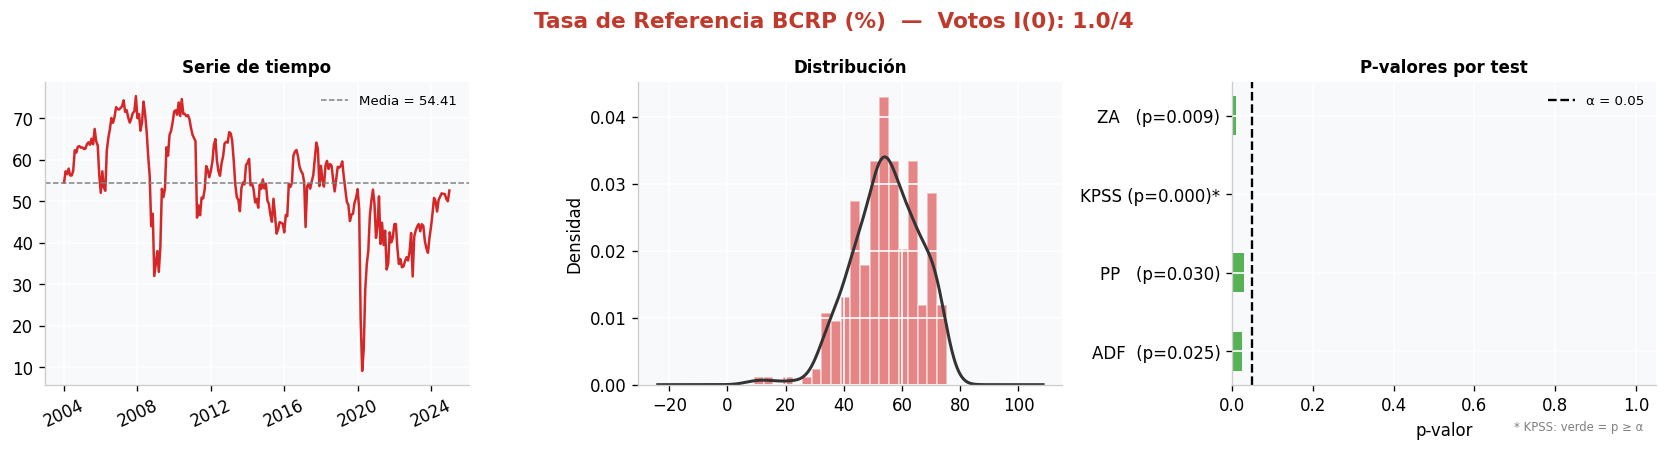

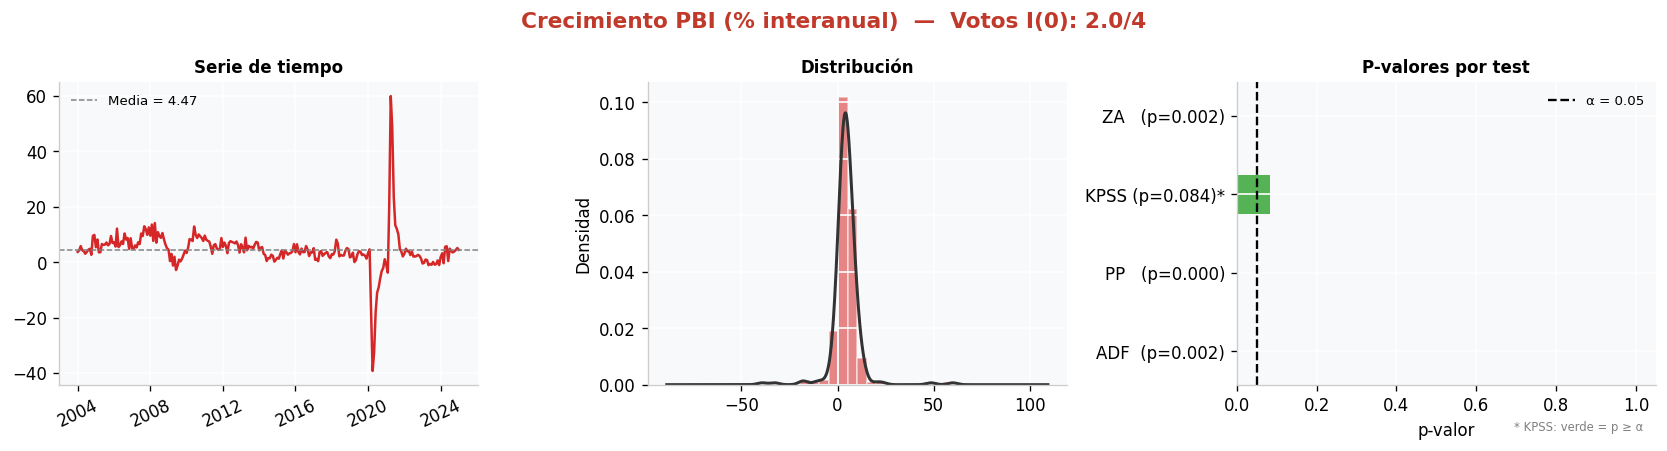

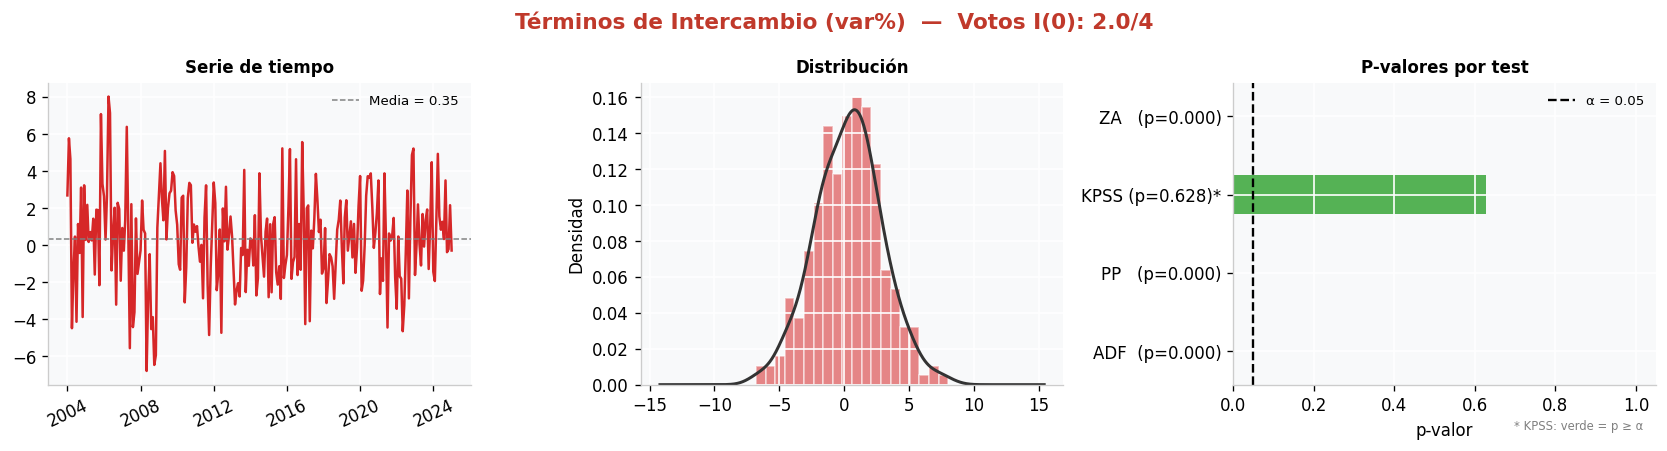

In [27]:
for col in df.columns:
    plot_variable_con_tests(col, df, tabla_tests, alpha=ALPHA)

In [28]:
state = construir_ui(
    df=df,
    tabla_tests=tabla_tests,
    alpha=ALPHA,
    freq=FREQ,
    ruta_output=RUTA_OUTPUT,
)
# Acceso externo al estado:
  state['df_work'] 
  state['trafos']   

IndentationError: unexpected indent (47795415.py, line 9)

---
## 7 · Verificación post-transformación completa

Ejecuta **después** de haber aplicado las transformaciones en la sección 6.

In [ ]:
df_work = state['df_work']

if df_work is not None and len(df_work) > 0:
    print('Corriendo tests completos sobre df_work...')
    tabla_post = correr_todos(df_work, alpha=ALPHA)

    display(
        tabla_estilizada(
            tabla_post,
            alpha=ALPHA,
            caption=f'Tests POST-transformación  |  DATA_VAR  |  α = {ALPHA}',
        )
    )

    n_I0 = tabla_post['Veredicto'].str.contains('✅').sum()
    n_I1 = tabla_post['Veredicto'].str.contains('❌').sum()
    print(f'\n📋 Resumen: {n_I0} variables I(0) ✅  |  {n_I1} variables I(1) ❌')

    if n_I1 > 0:
        vars_I1 = tabla_post[tabla_post['Veredicto'].str.contains('❌')].index.tolist()
        print(f'   Variables aún I(1): {vars_I1}')
        print('   → Considera diferenciar nuevamente o usar en niveles con cointegración.')
    else:
        print('   → Todas las variables son I(0). DATA_VAR lista para VAR/SVAR. 🎉')
else:
    print('⚠️  df_work está vacío. Aplica las transformaciones primero (sección 6).')


##  Guardar DATA_VAR *(alternativa sin widget)*
Si prefieres no usar el botón interactivo, corre esta celda directamente.

In [ ]:
df_work = state['df_work']
trafos  = state['trafos']

ruta = Path(RUTA_OUTPUT)
ruta.parent.mkdir(parents=True, exist_ok=True)
df_work.to_excel(ruta)

print(f'💾 DATA_VAR guardada en: {ruta.resolve()}')
print(f'   Shape   : {df_work.shape}')
print(f'   Rango   : {df_work.index.min().date()} → {df_work.index.max().date()}')
print(f'   Columnas: {list(df_work.columns)}')

if trafos:
    print('\n   Transformaciones aplicadas:')
    for col, lbl in trafos.items():
        print(f'   · {col}: {lbl}')
else:
    print('\n   ℹ️  Guardado en niveles originales (sin transformaciones).')